# Test lc_notebook_diff Extension

This notebook tests that the lc_notebook_diff JupyterLab extension is properly installed and enabled.
- Click on Diff tab in main area to open Diff widget

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmphlmw0jvh


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251224-154215',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpsrgap77o')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766558535.5753531 seconds


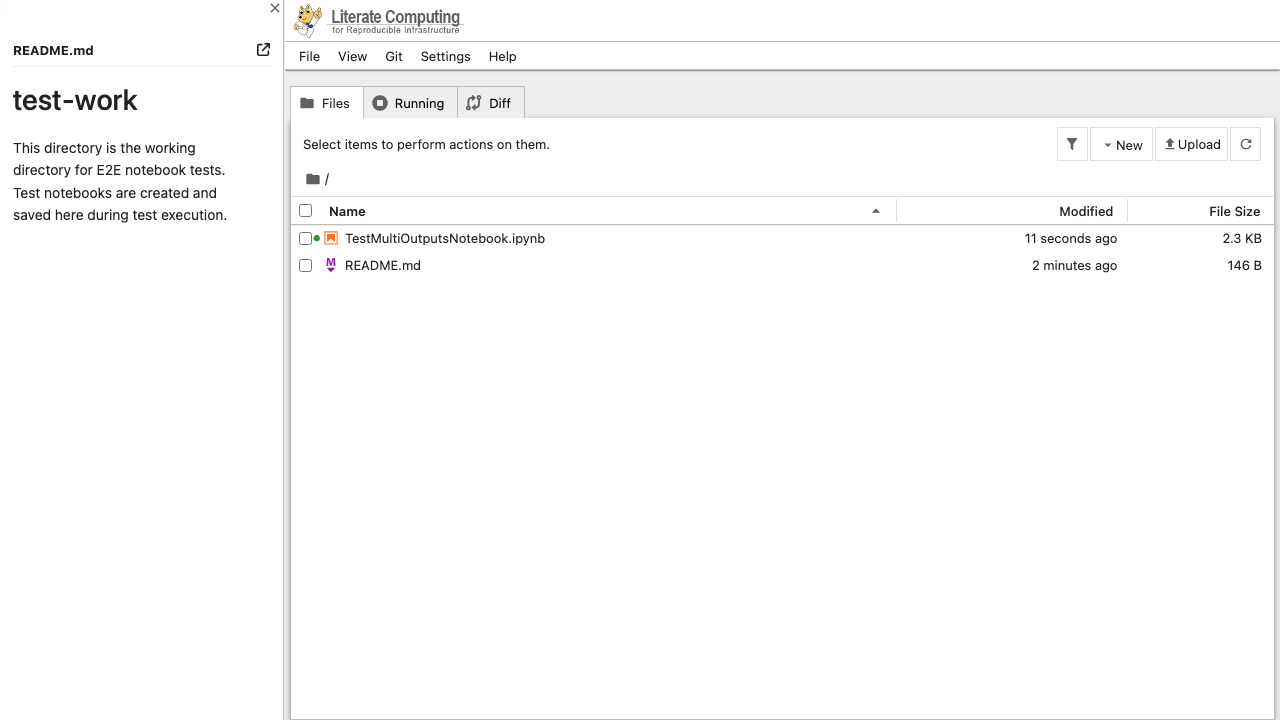

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Click on Diff tab in main area to open Diff widget

Start epoch: 1766558540.345151 seconds
✓ Clicked on Diff tab in main area
✓ Found 3 file input fields
✓ Show Diff button is visible


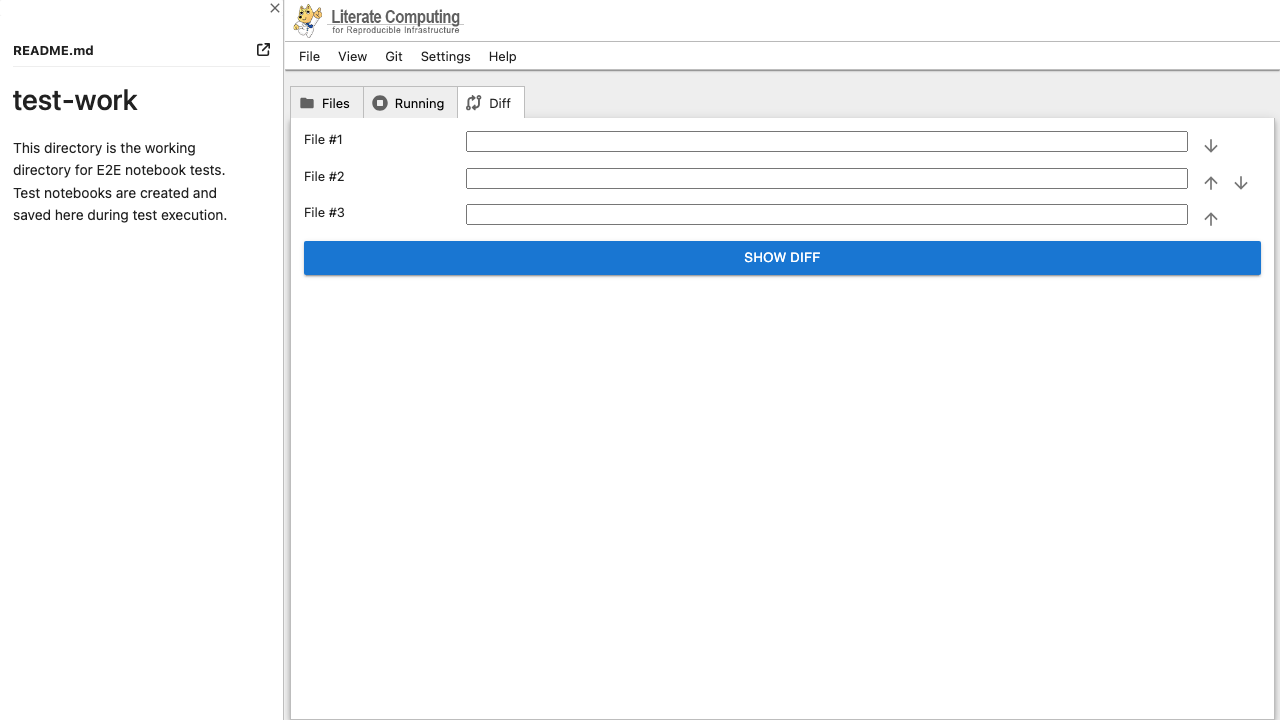

In [6]:
async def _step_click_on_diff_tab(page):
    # In Notebook 7, Diff widget is added as a tab in main area
    # Look for tab with "Diff" label
    diff_tab = page.locator('.lm-TabBar-tabLabel:has-text("Diff")')
    await expect(diff_tab).to_be_visible(timeout=transition_timeout)
    await diff_tab.click()
    
    print("✓ Clicked on Diff tab in main area")
    
    # Verify that file input fields are visible
    file_inputs = page.locator('.jupyter-notebook-diff-files input')
    await expect(file_inputs).to_have_count(3, timeout=transition_timeout)
    
    print("✓ Found 3 file input fields")
    
    # Verify that Show Diff button is visible
    show_diff_button = page.locator('button.jupyter-notebook-diff-show-diff')
    await expect(show_diff_button).to_be_visible(timeout=transition_timeout)
    
    print("✓ Show Diff button is visible")

await run_pw(_step_click_on_diff_tab)

## Cleanup

In [ ]:
await finish_pw_context()

In [8]:
!rm -rf {work_dir}